### **Air Quality Prediction**

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

**Load Dataset**

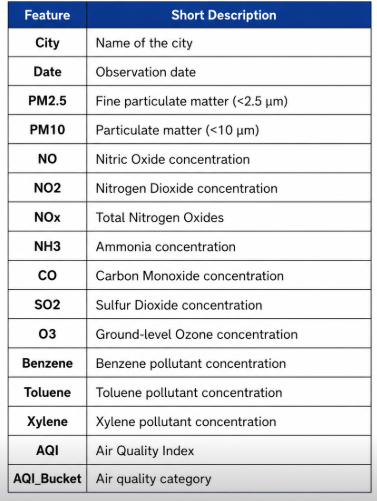

In [31]:
df = pd.read_csv("/content/city_day.csv")

print(df.head())

        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  


## **Basic Information**

In [3]:
#Check: Number of rows, Number of columns, Missing values and Data types
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(29531, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB
None
              PM2.5          PM10            NO           NO2           NOx  \
coun

**Remove Duplicate Records**

In [4]:
df.drop_duplicates(inplace=True)

print(df.shape)

(29531, 16)


**Convert Date Column**

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

**Exploratory Data Analysis**

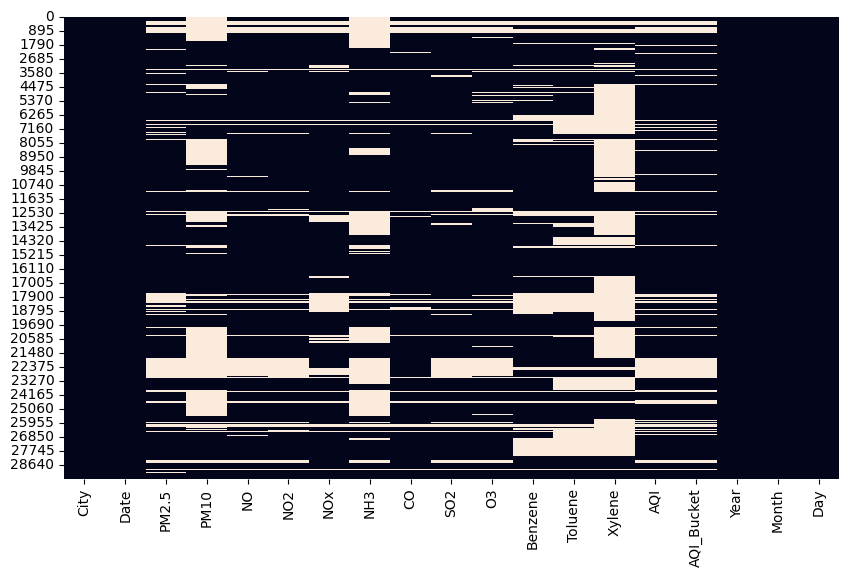

In [7]:
#Missing Values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

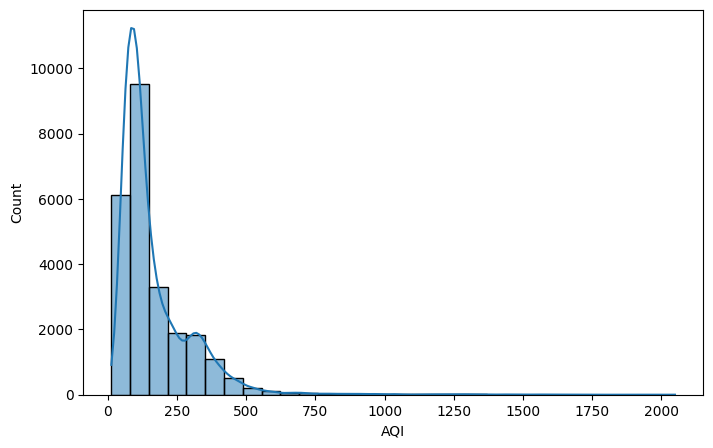

In [8]:
#AQI Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['AQI'], bins=30, kde=True)
plt.show()

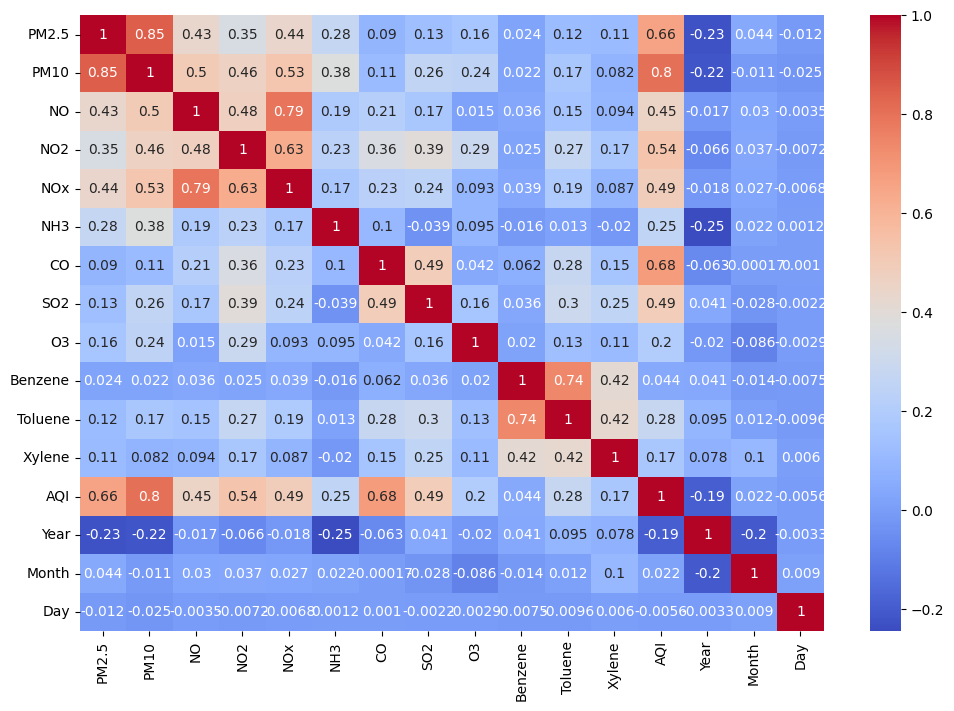

In [9]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

**Handle Missing Values**

In [10]:
#Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

In [11]:
#Median imputation
imputer = SimpleImputer(strategy='median')

df[num_cols] = imputer.fit_transform(df[num_cols])

In [12]:
print(df.isnull().sum())

City             0
Date             0
PM2.5            0
PM10             0
NO               0
NO2              0
NOx              0
NH3              0
CO               0
SO2              0
O3               0
Benzene          0
Toluene          0
Xylene           0
AQI              0
AQI_Bucket    4681
Year             0
Month            0
Day              0
dtype: int64


**Select Features**

In [13]:
#Choose predictor columns
features = [
    'PM2.5',
    'PM10',
    'NO',
    'NO2',
    'NOx',
    'NH3',
    'CO',
    'SO2',
    'O3',
    'Benzene',
    'Toluene',
    'Xylene'
]

In [14]:
X = df[features]

y = df['AQI']

**Train-Test Split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
print(X_train.shape)
print(X_test.shape)

(23624, 12)
(5907, 12)


**Train Random Forest Model**

In [17]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

**Predictions**

In [18]:
y_pred = rf.predict(X_test)

print(y_pred[:10])

[118.         118.         132.16       181.285      356.1
  88.74       117.62188535 141.285      116.82        85.015     ]


**Model Evaluation**

In [19]:
#MAE
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 19.92904084531318


In [20]:
#MSE
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 1869.2077722575327


In [21]:
#RMSE
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 43.23433557090397


In [22]:
#R²
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.8785792132964824


**Actual vs Predicted**

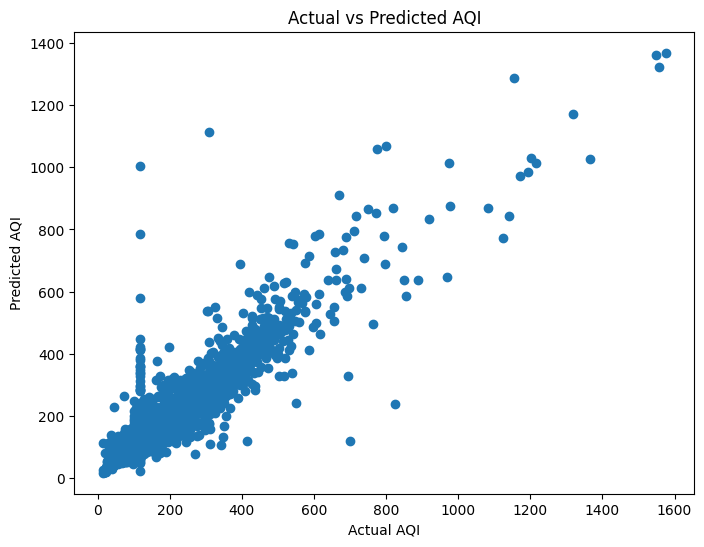

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.title("Actual vs Predicted AQI")

plt.show()

**Feature Importance**

In [24]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

    Feature  Importance
0     PM2.5    0.463422
6        CO    0.351738
1      PM10    0.055850
2        NO    0.033272
3       NO2    0.017179
4       NOx    0.016948
8        O3    0.015784
7       SO2    0.015366
10  Toluene    0.011462
9   Benzene    0.007395
11   Xylene    0.006982
5       NH3    0.004600


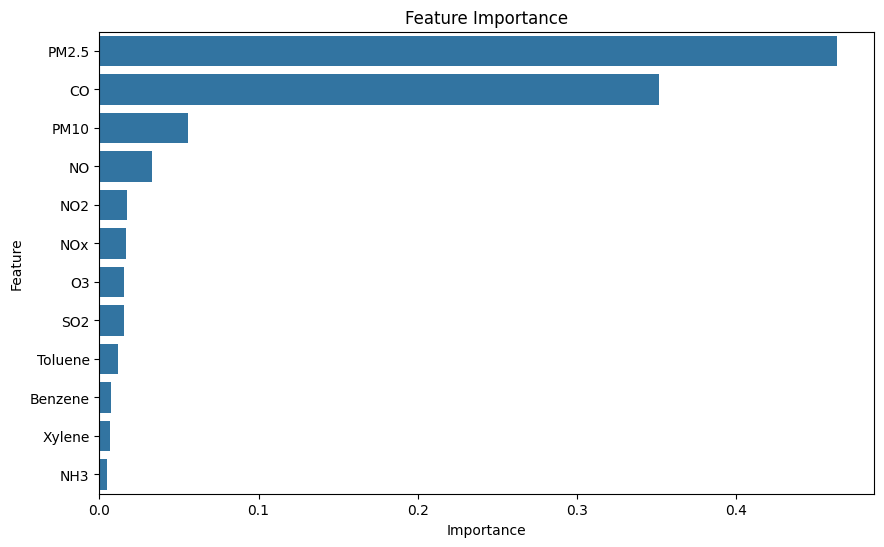

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

In [26]:
# =========================
# Predicted AQI Analysis
# =========================

def aqi_analysis(aqi):

    if 0 <= aqi <= 50:
        category = "Good"
        impact = "Minimal Impact"

    elif 51 <= aqi <= 100:
        category = "Satisfactory"
        impact = "Minor breathing discomfort to sensitive people"

    elif 101 <= aqi <= 200:
        category = "Moderate"
        impact = ("Breathing discomfort to people with lung disease, "
                  "heart disease, children and older adults")

    elif 201 <= aqi <= 300:
        category = "Poor"
        impact = "Breathing discomfort to people on prolonged exposure"

    elif 301 <= aqi <= 400:
        category = "Very Poor"
        impact = "Respiratory illness to people on prolonged exposure"

    else:
        category = "Severe"
        impact = "Respiratory effects even on healthy people"

    return category, impact

**Predict New Data**

In [27]:
# Predict AQI for new sample
sample = pd.DataFrame({
    'PM2.5':[120],
    'PM10':[180],
    'NO':[25],
    'NO2':[40],
    'NOx':[55],
    'NH3':[18],
    'CO':[2.3],
    'SO2':[14],
    'O3':[28],
    'Benzene':[5],
    'Toluene':[12],
    'Xylene':[3]
})
predicted_aqi = rf.predict(sample)[0]

category, impact = aqi_analysis(predicted_aqi)

print("\n" + "="*50)
print("AIR QUALITY PREDICTION REPORT")
print("="*50)

print(f"Predicted AQI : {predicted_aqi:.2f}")
print(f"AQI Category  : {category}")
print(f"Health Impact : {impact}")

print("="*50)


AIR QUALITY PREDICTION REPORT
Predicted AQI : 282.13
AQI Category  : Poor
Health Impact : Breathing discomfort to people on prolonged exposure


In [28]:
!pip install twilio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.6 MB/s eta 0:00:00


In [32]:
from twilio.rest import Client

account_sid = "AC550f8962374e0245929310b2dcb575df"
auth_token = "c4459af654c0dd953cc015a6431108c1"

if predicted_aqi > 300:
    client = Client(account_sid, auth_token)

    client.messages.create(
        body=f"🚨 AQI ALERT!\nCurrent AQI: {predicted_aqi:.1f}\nAvoid outdoor activities.",
        from_="+18777804236",
        to="+919335120267"
    )

    st.warning("AQI Alert SMS Sent!")